#**Sentiment Analysis**

The dataset is loaded from official IMDB website.
**Description:** Contains 50,000 movie reviews split into 25,000 for training and 25,000 for testing. The labels are binary: positive or negative.

In [1]:
import tensorflow_datasets as tfds

# 1. Load the IMDb reviews dataset
(train_data, test_data), info = tfds.load(
    'imdb_reviews',
    split=('train', 'test'),
    as_supervised=True,  # Loads data as (text, label) pairs
    with_info=True
)

# 2. Print some information about the dataset
print(f"Dataset contains {info.splits['train'].num_examples} training examples.")
print(f"Dataset contains {info.splits['test'].num_examples} testing examples.")
print("\n--- Here are a few examples ---")

# 3. Show the first 3 reviews from the training set
for i, (review, label) in enumerate(train_data.take(3)):
  # The review is a Tensor, so we convert it to a readable string
  review_text = review.numpy().decode('utf-8')

  # The label is 0 for negative and 1 for positive
  sentiment = "Positive" if label.numpy() == 1 else "Negative"

  print(f"\n--- Example {i+1} ---")
  print(f"Sentiment: {sentiment}")
  # Print the first 300 characters of the review
  print(f"Review: {review_text[:300]}...")

ModuleNotFoundError: No module named 'tensorflow_datasets'

In [ ]:
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# 1. Load the dataset (as you did before)
(train_data, test_data), info = tfds.load(
    'imdb_reviews',
    split=('train', 'test'),
    as_supervised=True,
    with_info=True
)

# 2. Convert the tf.data.Dataset to a list of (review, label) pairs
print("Converting dataset to Pandas DataFrame...")
training_reviews = []
for review_tensor, label_tensor in tfds.as_numpy(train_data):
    review = review_tensor.decode('utf-8')
    label = "Positive" if label_tensor == 1 else "Negative"
    training_reviews.append((review, label))

# 3. Create the DataFrame
df = pd.DataFrame(training_reviews, columns=['review', 'sentiment'])

print("DataFrame created successfully!")

Converting dataset to Pandas DataFrame...
DataFrame created successfully!


* Firstly we loaded the dataframe using tf.Data.dataset, now we convert dataet to dataframe for performing EDA to understand our data better.

* The data is now loaded into a DataFrame named df
with two columns: review (the text) and sentiment (the label). We can now begin our analysis.

In [ ]:
# Basic DataFrame Inspection/INFORMATION
print("Basic Info \n\n")
# Check for data types and non-null values
df.info()

print("\nData Head ")
# Look at the first few reviews to spot obvious issues (like HTML)
df.head()

Basic Info 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     25000 non-null  object
 1   sentiment  25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB

Data Head 


,review,sentiment
0,This was an absolutely terrible movie. Don't b...,Negative
1,"I have been known to fall asleep during films,...",Negative
2,Mann photographs the Alberta Rocky Mountains i...,Negative
3,This is the kind of film for a snowy Sunday af...,Positive
4,"As others have mentioned, all the women that g...",Positive


In [ ]:
# Look at the first review to spot obvious issues
print("\n--- First Review Example ---")
print(df.iloc[0]['review']) # Print the full text of the first review


--- First Review Example ---
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.


OBSERVATION:


*   Looking at the raw text of the first review. There is "noise" that the model will not understand.





--- Class Distribution ---
sentiment
Negative    12500
Positive    12500
Name: count, dtype: int64


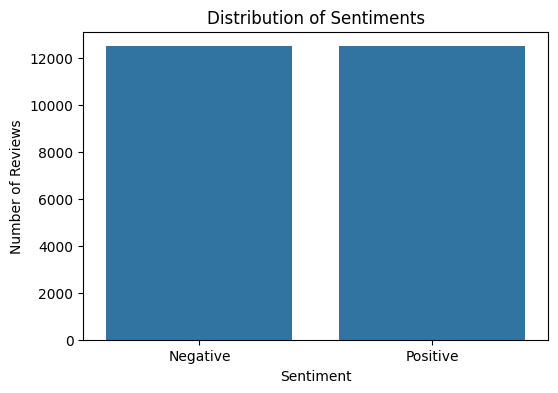

In [ ]:
# Class Distribution (Numerical)
print("\n--- Class Distribution ---")
print(df['sentiment'].value_counts())

# Class Distribution (Graphical)
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

OBSERVATION:

*   The median length and distribution for "Positive" and "Negative" reviews are very similar. This tells us that review length itself is probably not a good predictor of sentiment.




--- Review Length Statistics (Characters) ---
count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64


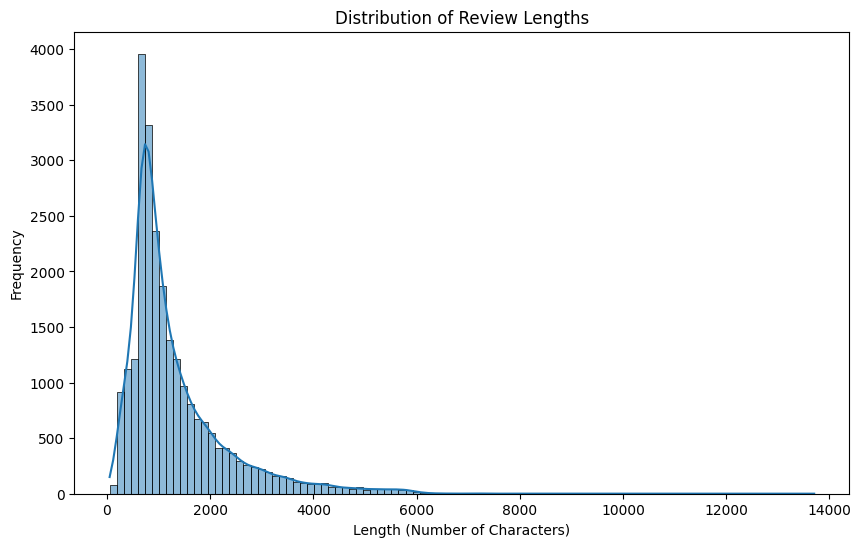

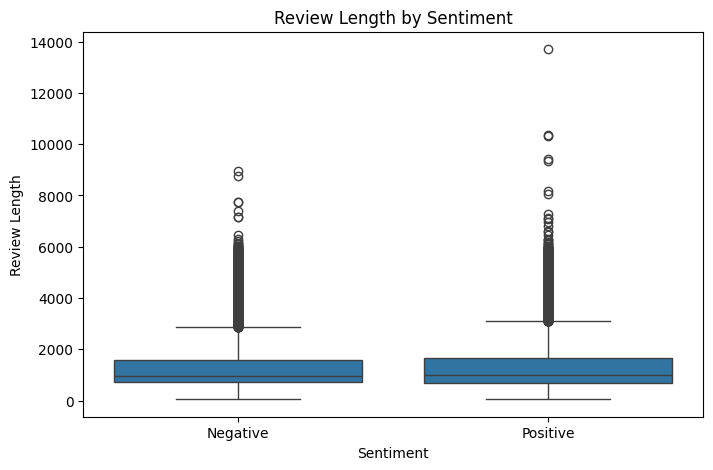

In [ ]:
#REVIEW LENGTH ANALYSIS
# Create a new column for the length (number of characters) of each review
df['review_length'] = df['review'].apply(len)

# 2. Get the numerical statistics of this new column
print("\n--- Review Length Statistics (Characters) ---")
print(df['review_length'].describe())

# 3. Plot a histogram to see the distribution of lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=100, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Length (Number of Characters)')
plt.ylabel('Frequency')
plt.show()

# 4. Plot a boxplot to see if length differs by sentiment
plt.figure(figsize=(8, 5))
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

* From describe(): There is a huge variation in length. The shortest review is very small (e.g., ~70 characters), while the longest is massive (e.g., ~13,000+ characters). The average (mean) is around 1,300 characters.

* From Histogram: The distribution is highly right-skewed. This means most reviews are in the 0-4,000 character range, but there is a "long tail" of a few extremely long reviews.

* From Boxplot: The median length and distribution for "Positive" and "Negative" reviews are very similar. This tells us that review length itself is probably not a good predictor of sentiment.


--- Generating Word Cloud for All Reviews ---


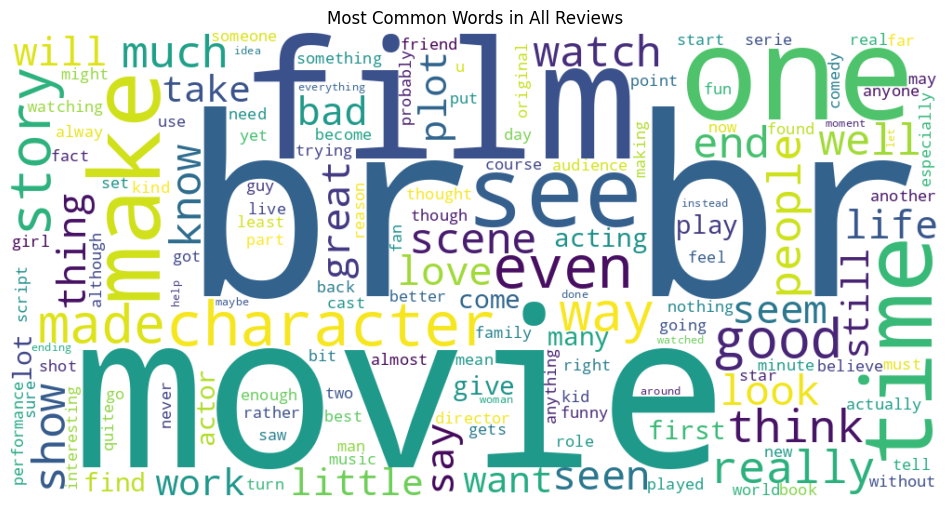

In [ ]:
#Common words analysis

# 1. Join all reviews into one giant string for a general word cloud
all_reviews_text = " ".join(df['review'])

# 2. Create the word cloud
print("\n--- Generating Word Cloud for All Reviews ---")
wordcloud_all = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=150
).generate(all_reviews_text)

# 3. Plot the word cloud
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.title('Most Common Words in All Reviews')
plt.axis('off') # Hide the axes
plt.show()

# 4. (Optional but good) Compare Positive vs. Negative clouds
positive_text = " ".join(df[df['sentiment'] == 'Positive']['review'])
negative_text = " ".join(df[df['sentiment'] == 'Negative']['review'])

The resulting word cloud will be dominated by a few key types of words:

    Noise: The word "br" will be very large. This is the text left over from the <br /> HTML tag we already found.

    Stopwords: Words like "the", "a", "is", "of", "and", "in" will be massive. These words carry no sentiment and just add noise.

    Dataset-Specific Words: Words like "movie" and "film" will also be huge. Since every review is about a movie or film, these words don't help us tell the difference between a good or bad one.

#**DATA PREPROCESSING**

#PRE PROCESSING STEPS:
For every review, we must:

  * Remove HTML Tags (Finding from Step 1)

   * Convert to Lowercase (Finding from Step 3)

  * Remove Punctuation (Finding from Step 3)

  * Tokenize (Split the text string into a list of individual words).

  * Remove Stopwords (including common words and our custom list: "br", "movie", "film") (Finding from Step 3).

  * Pad and Truncate all reviews to a uniform MAX_LENGTH (Finding from Step 2).

In [ ]:

import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download the NLTK resources we need (only required once)
nltk.download('stopwords')
nltk.download('punkt')

# --- Our Preprocessing Plan (from EDA) ---
# 1. Define our custom stopword list
# We start with the default English list
stop_words = set(stopwords.words('english'))
# We add the dataset-specific noise we found in the word cloud
custom_stop_words = {'br', 'movie', 'film'}
stop_words.update(custom_stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
def preprocess_text(text):
    """
    Cleans a single text string based on our EDA findings.
    """

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Convert to lowercase
    text = text.lower()

    # 3. Remove punctuation and numbers
    # This regex keeps only words and spaces.
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenize
    # To split the sentence into a list of individual words.
    tokens = word_tokenize(text)

    # 5. Remove stopwords
    # We use the stop_words list we defined.
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # oin words back into a single string
    # This puts our cleaned words back into a sentence
    return " ".join(filtered_tokens)

In [ ]:
print("Starting text preprocessing on 25,000 reviews...")
# This .apply() method runs our 'preprocess_text' function on every review.
# This might take 10-20 seconds.
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("Preprocessing complete!")

# Check the 'Before' and 'After'
print("\n--- Example of Cleaning ---")
print("Original Review:")
print(df['review'].iloc[0])
print("\nCleaned Review:")
print(df['cleaned_review'].iloc[0])

Starting text preprocessing on 25,000 reviews...
Preprocessing complete!

--- Example of Cleaning ---
Original Review:
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.

Cleaned Review:
absolutely terrible dont lured christopher walken michael ironside great actors must simply worst role history even great acting could redeem movies ridic

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Define model parameters based on our EDA ---

# Vocab Size: The total number of unique words to keep.
# We'll set it to 10,000.
MAX_FEATURES = 10000

# Max Length: The fixed length for all reviews.
# A length of 250 words is a common and effective choice.
MAX_LENGTH = 250

# --- Keras Tokenizer ---
# 1. Builds a "vocabulary" of the top 10,000 words.
# 2. Converts each word into a unique integer.
tokenizer = Tokenizer(num_words=MAX_FEATURES)
tokenizer.fit_on_texts(df['cleaned_review'])

# Convert our cleaned reviews into sequences of integers
X = tokenizer.texts_to_sequences(df['cleaned_review'])

# --- Keras Padding ---
# Why? To fix the length problem from our EDA (Step 2).
# This makes every review 250 integers long.
# - 'post' means it adds padding (0s) to the END of short reviews.
# - 'post' means it truncates (cuts off) long reviews from the END.
X_padded = pad_sequences(X, maxlen=MAX_LENGTH, padding='post', truncating='post')

# --- Prepare Labels ---
# We also need to convert our "Positive" / "Negative" labels to 1s and 0s.
y = (df['sentiment'] == 'Positive').astype(int).values

In [ ]:
print(f"\nShape of our final data (X_padded): {X_padded.shape}")
print(f"Shape of our final labels (y): {y.shape}")

print("\nFirst cleaned review (text):")
print(df['cleaned_review'].iloc[0])

print("\nFirst cleaned review (now a vector of numbers):")
print(X_padded[0])


Shape of our final data (X_padded): (25000, 250)
Shape of our final labels (y): (25000,)

First cleaned review (text):
absolutely terrible dont lured christopher walken michael ironside great actors must simply worst role history even great acting could redeem movies ridiculous storyline early nineties us propaganda piece pathetic scenes columbian rebels making cases revolutions maria conchita alonso appeared phony pseudolove affair walken nothing pathetic emotional plug devoid real meaning disappointed movies like ruining actors like christopher walkens good name could barely sit

First cleaned review (now a vector of numbers):
[ 302  270   18 1198 3345  373   16   59  119  209  140  111  360    4
   16   34   24 5346   20  512  605  284 8872   72 2303  296 1055   48
 7198  146 2668 2706 1297 4648 1402 3345   63 1055  768 7649 3864   55
 1090  541   20    2 6993   59    2 1198    3  285   24 1033  733    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0  

In [ ]:
#Splitting our data for model building
from sklearn.model_selection import train_test_split


# We split all three at the same time.
# random_state=42 ensures we get the same "random" split every time we run this.
X_text_train, X_text_test, X_pad_train, X_pad_test, y_train, y_test = train_test_split(
    df['cleaned_review'],
    X_padded,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training data points: {len(y_train)}")
print(f"Testing data points: {len(y_test)}")

Training data points: 20000
Testing data points: 5000


#**MODEL BUILDING**

#1-BULDING SVM MODEL


BUILDING THE MODEL
   * An SVM cannot read raw text. We must convert our X_text_train and X_text_test into numbers. TF-IDF (Term Frequency-Inverse Document Frequency) is a classic method that scores words based on how important they are to a specific review, not just how frequent they are.

In [ ]:
#VECTORIZING THE TEXT

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Initialize the vectorizer
# We'll limit it to the top 5000 most important words
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
# This learns the vocabulary and transforms the text into a matrix
X_tfidf_train = tfidf_vectorizer.fit_transform(X_text_train)

# Only transform the test data
# We use the vocabulary learned from the training data
X_tfidf_test = tfidf_vectorizer.transform(X_text_test)

print(f"Shape of TF-IDF training data: {X_tfidf_train.shape}")

Shape of TF-IDF training data: (20000, 5000)


In [ ]:
#Train the SVM Model

'''Now that we have numerical TF-IDF vectors (X_tfidf_train) and labels (y_train),
we can "fit" (train) our SVM model. We'll use LinearSVC, which is a fast and powerful SVM optimized
for text.'''

'Now that we have numerical TF-IDF vectors (X_tfidf_train) and labels (y_train),\nwe can "fit" (train) our SVM model. We\'ll use LinearSVC, which is a fast and powerful SVM optimized\nfor text.'

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the model
# random_state=42 ensures the model is built the same way each time
svm_model = LinearSVC(random_state=42)

# 2. Train the model
print("Training SVM model...")
svm_model.fit(X_tfidf_train, y_train)
print("SVM training complete!")

# 3. Make predictions on the unseen test data
y_pred_svm = svm_model.predict(X_tfidf_test)

Training SVM model...
SVM training complete!


In [ ]:
#EVALUATING THE SVM MODEL
'''This is the moment of truth. We compare the model's predictions (y_pred_svm)
against the true labels (y_test) to see how accurate it is.'''

"This is the moment of truth. We compare the model's predictions (y_pred_svm)\nagainst the true labels (y_test) to see how accurate it is."

In [ ]:
# 1. Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"\n--- SVM Model Results ---")
print(f"Accuracy: {svm_accuracy * 100:.2f}%")

# 2. Show a detailed report (precision, recall, f1-score)
# Label 0 = Negative, Label 1 = Positive
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))


--- SVM Model Results ---
Accuracy: 86.90%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      2576
    Positive       0.86      0.88      0.87      2424

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



# 2-RNN : DEEP LEARNING APPROACH

Building Model Architecture for RNN

We are defining the "brain" of our model, layer by layer.

    Embedding: This is the most important layer. It converts our integer sequences (e.g., [5, 20, 301]) into dense vector representations. It learns the meaning and relationships between words (e.g., "good" and "great" will have similar vectors).

    LSTM: This is our Recurrent Neural Network layer. It reads the sequence of word vectors one by one and "remembers" the context to understand the overall sentiment.

    Dense: A final, "normal" neural network layer that takes the LSTM's output and makes a final 0 or 1 prediction. We use 'sigmoid' activation because it's perfect for binary (0 or 1) classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Model Parameters (from our preprocessing) ---
MAX_FEATURES = 10000  # Our vocabulary size
MAX_LENGTH = 250      # Our sequence length
EMBEDDING_DIM = 128   # The size of the vector for each word

# Define the model
rnn_model = Sequential()

# Add the Embedding layer
rnn_model.add(Embedding(
    input_dim=MAX_FEATURES,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LENGTH
))

# Add the RNN layer (LSTM is a powerful type of RNN)
# 64 is the number of "memory units" in the layer
rnn_model.add(LSTM(64))

# 4. (Optional but recommended) Add Dropout
# This randomly "drops" 50% of neurons to prevent overfitting
rnn_model.add(Dropout(0.5))

# 5. Add the final Output layer
rnn_model.add(Dense(1, activation='sigmoid'))

# Compile the model
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Print a summary of our model
rnn_model.summary()

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#Compile the model and train it
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("Training RNN MODEL")
history = rnn_model.fit(
    X_pad_train,
    y_train,
    epochs=14,
    batch_size=64,
    validation_data=(X_pad_test, y_test),
    callbacks=[early_stop]
)
print("RNN training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training RNN MODEL
Epoch 1/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5008 - loss: 0.6941 - val_accuracy: 0.4848 - val_loss: 0.6939
Epoch 2/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5086 - loss: 0.6921 - val_accuracy: 0.5242 - val_loss: 0.6917
Epoch 3/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5237 - loss: 0.6879 - val_accuracy: 0.5246 - val_loss: 0.6906
Epoch 4/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5275 - loss: 0.6695 - val_accuracy: 0.5260 - val_loss: 0.7026
Epoch 5/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5315 - loss: 0.6525 - val_accuracy: 0.4924 - val_loss: 0.7114
Epoch 6/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5349 - loss: 0.6562 - val_accuracy: 0.4914 - val_loss: 0.7033
Epoch 7/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6431 - loss: 0.5977 - val_accuracy: 0.8106 - val_loss: 0.4444
Epoch 8/14
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8744 - loss

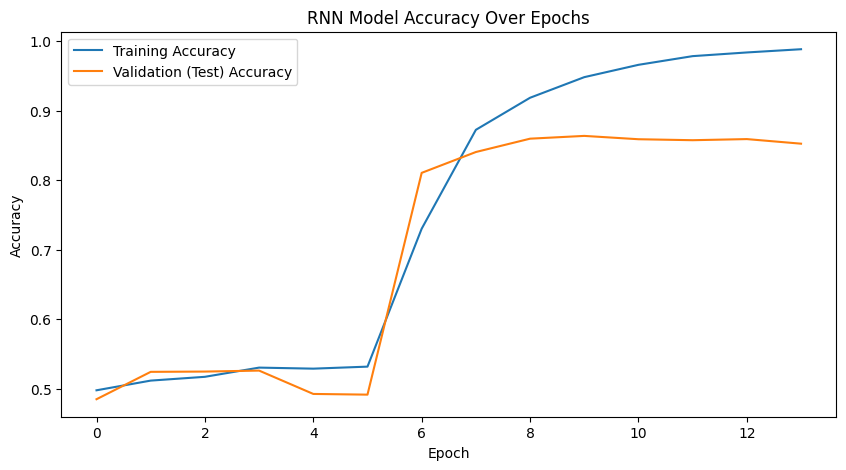

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- RNN Model Results ---
Final Test Accuracy: 85.98%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.80      0.85      2576
    Positive       0.81      0.93      0.86      2424

    accuracy                           0.86      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000



In [ ]:
#Evaluating the RNN model
# Plot training vs. validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy')
plt.title('RNN Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Get the final classification report
y_pred_prob_rnn = rnn_model.predict(X_pad_test)
y_pred_rnn = (y_pred_prob_rnn > 0.5).astype(int)

# Print the report
rnn_accuracy = accuracy_score(y_test, y_pred_rnn)
print(f"\n--- RNN Model Results ---")
print(f"Final Test Accuracy: {rnn_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rnn, target_names=['Negative', 'Positive']))

In [ ]:
#save the model
rnn_model.save('Sentiment_Analysis.h5')

#download the model
from google.colab import files
files.download('Sentiment_Analysis.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>